# Takeda Compensation Analytics — Solution Notebook

## Complete Solution with Explanations

This notebook provides the full solution to the take-home challenge, demonstrating PhD-level data science methodology for compensation equity analysis.

In [6]:
!pip3 install -q pandas numpy scikit-learn statsmodels matplotlib seaborn scipy


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [7]:
# === Setup & Imports ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set publication-quality defaults
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
TAKEDA_RED = '#E60012'
TAKEDA_BLUE = '#003B71'
MALE_COLOR = '#4A90D9'
FEMALE_COLOR = '#E85D75'

print("Setup complete.")

Setup complete.


## Part 0: Data Generation

Run the data generator from the problem notebook (identical code).

In [8]:
# Copy the generate_challenge_data function from problem.ipynb and run it
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

# We'll inline the generator for self-containment
def generate_challenge_data(seed=2024):
    rng = np.random.default_rng(seed)
    N = 5200
    COUNTRIES = {
        "US": {"mult": 1.0, "gap": 0.08, "n_frac": 0.25},
        "JP": {"mult": 0.75, "gap": 0.12, "n_frac": 0.14},
        "DE": {"mult": 0.90, "gap": 0.06, "n_frac": 0.10},
        "UK": {"mult": 0.85, "gap": 0.09, "n_frac": 0.08},
        "CH": {"mult": 1.15, "gap": 0.05, "n_frac": 0.05},
        "BR": {"mult": 0.45, "gap": 0.10, "n_frac": 0.08},
        "CN": {"mult": 0.50, "gap": 0.11, "n_frac": 0.10},
        "IN": {"mult": 0.30, "gap": 0.14, "n_frac": 0.08},
        "SG": {"mult": 0.80, "gap": 0.07, "n_frac": 0.06},
        "AU": {"mult": 0.88, "gap": 0.06, "n_frac": 0.06},
    }
    BASE_BY_LEVEL = {1:45000,2:55000,3:68000,4:82000,5:100000,6:125000,7:155000,8:195000,9:250000,10:330000}
    DEPTS = {"R&D":(0.30,1.10),"Commercial":(0.25,1.05),"Manufacturing":(0.20,0.95),"Corporate":(0.15,1.00),"Medical Affairs":(0.10,1.08)}
    EDU_PREMIUM = {"Bachelor's":0.0,"Master's":0.08,"PhD":0.18,"MD":0.25,"MBA":0.15}
    countries = list(COUNTRIES.keys()); country_probs = [COUNTRIES[c]["n_frac"] for c in countries]
    depts = list(DEPTS.keys()); dept_probs = [DEPTS[d][0] for d in depts]
    edus = list(EDU_PREMIUM.keys()); edu_probs = [0.25,0.30,0.20,0.10,0.15]
    records = []
    for i in range(N):
        eid = f"EMP-{i+1:05d}"
        gender = rng.choice(["M","F"], p=[0.55,0.45])
        country = rng.choice(countries, p=country_probs)
        dept = rng.choice(depts, p=dept_probs)
        edu = rng.choice(edus, p=edu_probs)
        lp = np.array([0.12,0.14,0.16,0.15,0.14,0.12,0.08,0.05,0.03,0.01]) if gender=="F" else np.array([0.08,0.10,0.13,0.14,0.15,0.14,0.11,0.08,0.05,0.02])
        level = rng.choice(range(1,11), p=lp)
        yrs = max(0, min(40, int(rng.normal(level*2.5, 3))))
        perf = rng.choice([1,2,3,4,5], p=[0.02,0.08,0.30,0.40,0.20] if gender=="F" else [0.02,0.06,0.25,0.40,0.27])
        tenure = max(0, min(yrs, int(rng.normal(yrs*0.6, 2))))
        hire_year = 2024 - tenure; hire_month = rng.integers(1,13)
        hire_date = f"{hire_year}-{hire_month:02d}-01"
        base = BASE_BY_LEVEL[level] * COUNTRIES[country]["mult"] * DEPTS[dept][1]
        base *= (1 + EDU_PREMIUM[edu]) * (1 + yrs*0.012) * (1 + (perf-3)*0.03)
        if gender == "F":
            gap = max(0, rng.normal(COUNTRIES[country]["gap"], COUNTRIES[country]["gap"]*0.3))
            base *= (1 - gap)
        base *= rng.normal(1.0, 0.05)
        base_salary = round(max(base, 20000), 2)
        bonus_pct = 0.05 + (level-1)*0.028
        bonus = round(base_salary * bonus_pct * rng.uniform(0.6, 1.4), 2)
        records.append({"employee_id":eid,"gender":gender,"country":country,"department":dept,
            "job_level":level,"education":edu,"years_experience":yrs,"tenure_years":tenure,
            "performance_rating":perf,"hire_date":hire_date,"base_salary":base_salary,
            "bonus":bonus,"total_compensation":round(base_salary+bonus,2)})
    df = pd.DataFrame(records)
    for col in ["education","performance_rating","years_experience","bonus"]:
        mask = rng.random(N) < 0.03; df.loc[mask, col] = np.nan
    dup_idx = rng.choice(N, size=50, replace=False)
    df = pd.concat([df, df.iloc[dup_idx].copy()], ignore_index=True)
    outlier_idx = rng.choice(len(df), size=15, replace=False)
    df.loc[outlier_idx[:8], "base_salary"] *= rng.uniform(3, 8, size=8)
    df.loc[outlier_idx[8:], "base_salary"] *= rng.uniform(0.05, 0.2, size=7)
    df.loc[outlier_idx, "total_compensation"] = df.loc[outlier_idx, "base_salary"] + df.loc[outlier_idx, "bonus"].fillna(0)
    gender_map = {"M":["M","Male","male","m"],"F":["F","Female","female","f"]}
    noise_idx = rng.choice(len(df), size=80, replace=False)
    for idx in noise_idx:
        g = df.loc[idx, "gender"]
        if g in gender_map: df.loc[idx, "gender"] = rng.choice(gender_map[g])
    neg_idx = rng.choice(len(df), size=10, replace=False)
    df.loc[neg_idx, "bonus"] = -abs(df.loc[neg_idx, "bonus"])
    return df.sample(frac=1, random_state=seed).reset_index(drop=True)

df_raw = generate_challenge_data()
print(f"Raw dataset shape: {df_raw.shape}")
df_raw.head()

Raw dataset shape: (5250, 13)


,employee_id,gender,country,department,job_level,education,years_experience,tenure_years,performance_rating,hire_date,base_salary,bonus,total_compensation
0,EMP-00940,M,CN,R&D,5,MBA,13.0,5,4.0,2019-03-01,70318.70,11348.39,81667.09
1,EMP-00193,F,IN,Manufacturing,4,MBA,NaN,6,3.0,2018-12-01,25545.23,2631.12,28176.35
2,EMP-04114,M,IN,Commercial,5,Bachelor's,13.0,8,2.0,2016-11-01,34464.76,5058.08,39522.84
3,EMP-01569,M,US,Commercial,4,Master's,12.0,4,4.0,2020-07-01,116238.45,16970.56,133209.01
4,EMP-04445,F,BR,Commercial,7,Master's,16.0,11,3.0,2013-03-01,90735.07,22827.15,113562.22


---
## Part 1: Data Quality Assessment & Preprocessing

### 1.1 Initial Profiling

In [9]:
# 1.1 Dataset Profiling
print("=" * 60)
print("DATASET PROFILE")
print("=" * 60)
print(f"\nShape: {df_raw.shape}")
print(f"\nData types:\n{df_raw.dtypes}")
print(f"\n--- Missing Values ---")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({"count": missing, "pct": missing_pct}).query("count > 0"))

print(f"\n--- Unique Values per Column ---")
for col in df_raw.columns:
    print(f"  {col}: {df_raw[col].nunique()}")

print(f"\n--- Numeric Summary ---")
df_raw.describe().round(2)

DATASET PROFILE

Shape: (5250, 13)

Data types:
employee_id            object
gender                 object
country                object
department             object
job_level               int64
education              object
years_experience      float64
tenure_years            int64
performance_rating    float64
hire_date              object
base_salary           float64
bonus                 float64
total_compensation    float64
dtype: object

--- Missing Values ---
                    count   pct
education             173  3.30
years_experience      162  3.09
performance_rating    177  3.37
bonus                 156  2.97

--- Unique Values per Column ---
  employee_id: 5200
  gender: 8
  country: 10
  department: 5
  job_level: 10
  education: 5
  years_experience: 33
  tenure_years: 21
  performance_rating: 5
  hire_date: 232
  base_salary: 5112
  bonus: 5043
  total_compensation: 5201

--- Numeric Summary ---


,job_level,years_experience,tenure_years,performance_rating,base_salary,bonus,total_compensation
count,5250.00,5088.00,5250.00,5073.00,5250.00,5094.00,5250.00
mean,4.59,11.14,6.22,3.78,110933.22,20787.11,131747.67
std,2.32,6.38,4.17,0.95,85050.36,25314.29,108450.67
min,1.00,0.00,0.00,1.00,3585.76,-62054.48,7296.96
25%,3.00,6.00,3.00,3.00,54683.68,5162.51,60426.61
50%,4.00,11.00,6.00,4.00,85888.66,11734.08,97861.47
75%,6.00,16.00,9.00,4.00,140378.78,26100.96,167476.21
max,10.00,32.00,20.00,5.00,1436260.53,233687.05,1479610.81


### 1.2 Identify & Fix Data Quality Issues

**Issues found:**
1. **Duplicate rows** (~50 exact duplicates from employee_id)
2. **Inconsistent gender encoding** (M/Male/male/m, F/Female/female/f)
3. **Missing values** in education, performance_rating, years_experience, bonus (~3%)
4. **Salary outliers** — extreme values from data entry errors (both high and low)
5. **Negative bonus values** — clawbacks that need special handling
6. **total_compensation inconsistency** — doesn't always equal base + bonus after outlier injection

In [10]:
df = df_raw.copy()
print(f"Starting rows: {len(df)}")

# --- Issue 1: Duplicates ---
# Identify by employee_id (true duplicates, not just similar records)
n_dups = df.duplicated(subset="employee_id", keep="first").sum()
print(f"\n1. DUPLICATES: Found {n_dups} duplicate employee_ids")
df = df.drop_duplicates(subset="employee_id", keep="first").reset_index(drop=True)
print(f"   After removal: {len(df)} rows")

# --- Issue 2: Inconsistent gender encoding ---
print(f"\n2. GENDER ENCODING: Unique values = {df['gender'].unique()}")
gender_clean = df["gender"].str.strip().str.upper().str[0]  # Take first char after upper
df["gender"] = gender_clean
print(f"   After cleaning: {df['gender'].unique()}")
print(f"   Distribution: {df['gender'].value_counts().to_dict()}")

# --- Issue 3: Missing values ---
print(f"\n3. MISSING VALUES:")
for col in ["education", "performance_rating", "years_experience", "bonus"]:
    n_miss = df[col].isnull().sum()
    pct = n_miss / len(df) * 100
    print(f"   {col}: {n_miss} ({pct:.1f}%)")

# Strategy: 
# - education: impute with mode (most common) — categorical, low missing %
# - performance_rating: impute with median (ordinal) 
# - years_experience: impute with median within same job_level (correlated)
# - bonus: impute using base_salary * level-appropriate bonus rate

df["education"] = df["education"].fillna(df["education"].mode()[0])

df["performance_rating"] = df.groupby("job_level")["performance_rating"].transform(
    lambda x: x.fillna(x.median())
)

df["years_experience"] = df.groupby("job_level")["years_experience"].transform(
    lambda x: x.fillna(x.median())
)

# For bonus, use median bonus/base ratio within same job_level
bonus_ratio_by_level = df.dropna(subset=["bonus"]).groupby("job_level").apply(
    lambda g: (g["bonus"] / g["base_salary"]).median()
)
for idx in df[df["bonus"].isnull()].index:
    level = df.loc[idx, "job_level"]
    df.loc[idx, "bonus"] = df.loc[idx, "base_salary"] * bonus_ratio_by_level.get(level, 0.1)

print("   Imputation complete — zero missing values remaining:", df.isnull().sum().sum())

# --- Issue 4: Salary outliers ---
# Use IQR method within each job_level to detect outliers
print(f"\n4. SALARY OUTLIERS:")
outlier_mask = pd.Series(False, index=df.index)
for level in df["job_level"].unique():
    level_mask = df["job_level"] == level
    q1 = df.loc[level_mask, "base_salary"].quantile(0.05)
    q3 = df.loc[level_mask, "base_salary"].quantile(0.95)
    iqr = q3 - q1
    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr
    level_outliers = level_mask & ((df["base_salary"] < lower) | (df["base_salary"] > upper))
    outlier_mask |= level_outliers

n_outliers = outlier_mask.sum()
print(f"   Found {n_outliers} salary outliers (>3 IQR from 5th/95th percentile within level)")
# Winsorize rather than drop — preserve the employee record
for idx in df[outlier_mask].index:
    level = df.loc[idx, "job_level"]
    level_salaries = df.loc[(df["job_level"] == level) & ~outlier_mask, "base_salary"]
    if df.loc[idx, "base_salary"] > level_salaries.median():
        df.loc[idx, "base_salary"] = level_salaries.quantile(0.95)
    else:
        df.loc[idx, "base_salary"] = level_salaries.quantile(0.05)
print(f"   Winsorized to 5th/95th percentile within level")

# --- Issue 5: Negative bonuses ---
n_neg = (df["bonus"] < 0).sum()
print(f"\n5. NEGATIVE BONUSES: {n_neg} records")
# Set to 0 — clawbacks shouldn't be penalized in equity analysis
df.loc[df["bonus"] < 0, "bonus"] = 0
print("   Set negative bonuses to 0 for equity analysis")

# --- Issue 6: Recalculate total_compensation ---
df["total_compensation"] = df["base_salary"] + df["bonus"]
print(f"\n6. Recalculated total_compensation = base_salary + bonus")

print(f"\n{'='*60}")
print(f"CLEAN DATASET: {df.shape}")
print(f"Missing: {df.isnull().sum().sum()}")
print(f"{'='*60}")

Starting rows: 5250

1. DUPLICATES: Found 50 duplicate employee_ids
   After removal: 5200 rows

2. GENDER ENCODING: Unique values = [np.str_('M') np.str_('F') np.str_('m') np.str_('Male') np.str_('female')
 np.str_('male') np.str_('Female') np.str_('f')]
   After cleaning: ['M' 'F']
   Distribution: {'M': 2889, 'F': 2311}

3. MISSING VALUES:
   education: 171 (3.3%)
   performance_rating: 176 (3.4%)
   years_experience: 158 (3.0%)
   bonus: 156 (3.0%)
   Imputation complete — zero missing values remaining: 0

4. SALARY OUTLIERS:
   Found 4 salary outliers (>3 IQR from 5th/95th percentile within level)
   Winsorized to 5th/95th percentile within level

5. NEGATIVE BONUSES: 8 records
   Set negative bonuses to 0 for equity analysis

6. Recalculated total_compensation = base_salary + bonus

CLEAN DATASET: (5200, 13)
Missing: 0


### 1.3 Feature Engineering

In [11]:
# Feature Engineering — create analytically useful derived features

# 1. Compa-ratio: employee salary vs. median for their level+country
# This is the standard HR metric for pay positioning
df["level_country_median"] = df.groupby(["job_level", "country"])["base_salary"].transform("median")
df["compa_ratio"] = df["base_salary"] / df["level_country_median"]

# 2. Bonus-to-base ratio — captures variable pay equity
df["bonus_ratio"] = df["bonus"] / df["base_salary"]

# 3. Experience-adjusted salary — salary per year of experience
# Useful for identifying whether experience is rewarded equally
df["salary_per_exp_year"] = df["base_salary"] / (df["years_experience"] + 1)  # +1 to avoid div/0

# 4. Tenure-to-experience ratio — how long they've been at Takeda vs. total career
df["tenure_ratio"] = df["tenure_years"] / (df["years_experience"] + 1)

# 5. Binary indicator for senior leadership (level 7+)
df["is_senior"] = (df["job_level"] >= 7).astype(int)

# 6. Gender binary for modeling
df["is_female"] = (df["gender"] == "F").astype(int)

# 7. Log compensation (for regression)
df["log_total_comp"] = np.log(df["total_compensation"])
df["log_base_salary"] = np.log(df["base_salary"])

print("Engineered features:")
print(df[["compa_ratio", "bonus_ratio", "salary_per_exp_year", "tenure_ratio", "is_senior"]].describe().round(3))

Engineered features:
       compa_ratio  bonus_ratio  salary_per_exp_year  tenure_ratio  is_senior
count     5200.000     5200.000             5200.000      5200.000   5200.000
mean         1.007        0.152            10743.093         0.467      0.217
std          0.169        0.098             8676.943         0.225      0.412
min          0.080        0.000              415.030         0.000      0.000
25%          0.919        0.092             6319.260         0.364      0.000
50%          1.000        0.139             8998.564         0.500      0.000
75%          1.086        0.198            12141.909         0.611      0.000
max          6.666        2.888            81655.260         2.000      1.000


---
## Part 2: Exploratory Data Analysis

### 2.1 Univariate Distributions

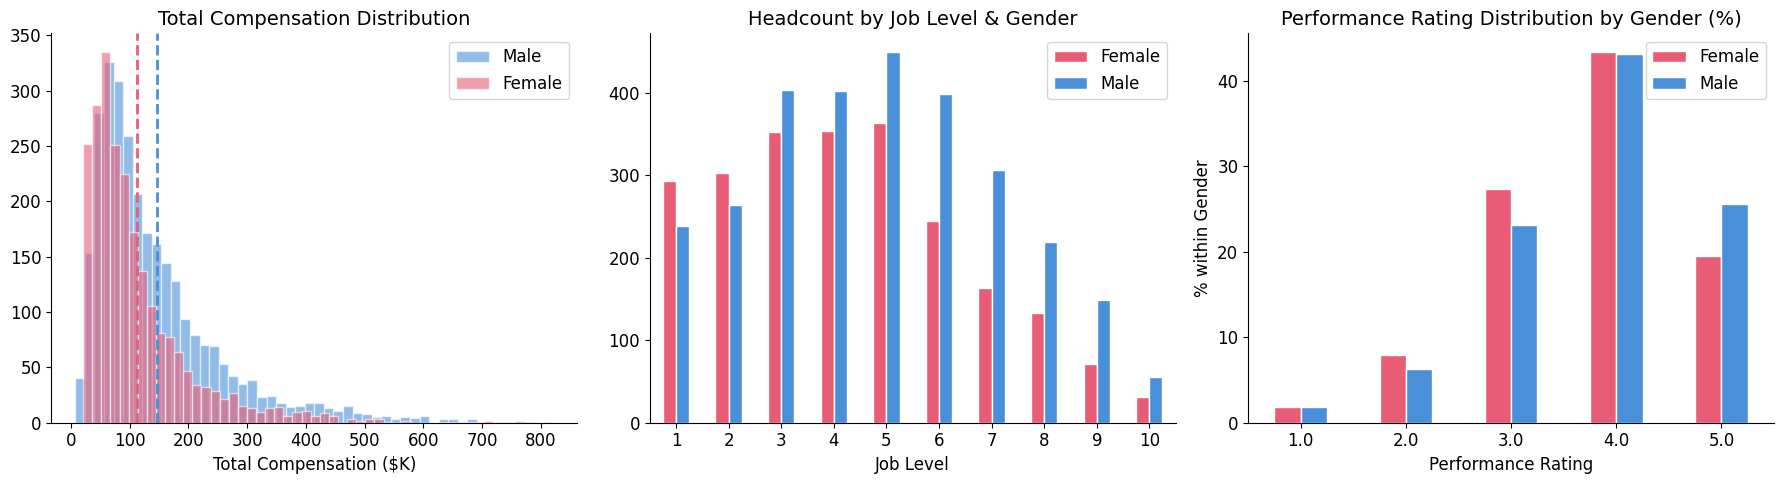

In [12]:
# 2.1 Compensation distribution by gender — overlaid histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total compensation
for g, color, label in [("M", MALE_COLOR, "Male"), ("F", FEMALE_COLOR, "Female")]:
    subset = df[df["gender"] == g]["total_compensation"] / 1000
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor="white")
axes[0].set_title("Total Compensation Distribution")
axes[0].set_xlabel("Total Compensation ($K)")
axes[0].legend()
axes[0].axvline(df[df["gender"]=="M"]["total_compensation"].mean()/1000, color=MALE_COLOR, ls="--", lw=2)
axes[0].axvline(df[df["gender"]=="F"]["total_compensation"].mean()/1000, color=FEMALE_COLOR, ls="--", lw=2)

# Job level distribution
level_gender = df.groupby(["job_level", "gender"]).size().unstack(fill_value=0)
level_gender.plot(kind="bar", ax=axes[1], color=[FEMALE_COLOR, MALE_COLOR], edgecolor="white")
axes[1].set_title("Headcount by Job Level & Gender")
axes[1].set_xlabel("Job Level")
axes[1].legend(["Female", "Male"])
axes[1].tick_params(axis='x', rotation=0)

# Performance rating by gender
perf_gender = df.groupby(["performance_rating", "gender"]).size().unstack(fill_value=0)
perf_pct = perf_gender.div(perf_gender.sum(axis=0), axis=1) * 100
perf_pct.plot(kind="bar", ax=axes[2], color=[FEMALE_COLOR, MALE_COLOR], edgecolor="white")
axes[2].set_title("Performance Rating Distribution by Gender (%)")
axes[2].set_xlabel("Performance Rating")
axes[2].set_ylabel("% within Gender")
axes[2].legend(["Female", "Male"])
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

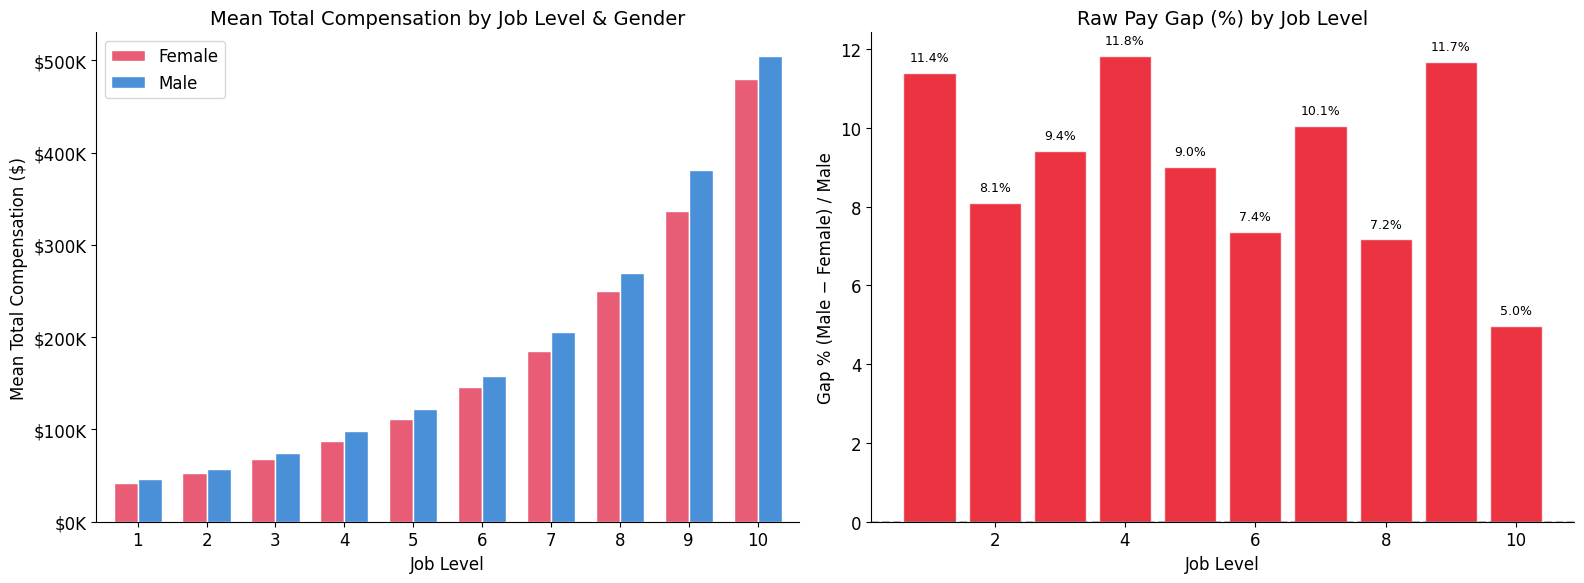

In [13]:
# 2.2 Bivariate: Average compensation by job level and gender
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean comp by level × gender
level_comp = df.groupby(["job_level", "gender"])["total_compensation"].mean().unstack()
level_comp.plot(kind="bar", ax=axes[0], color=[FEMALE_COLOR, MALE_COLOR], edgecolor="white", width=0.7)
axes[0].set_title("Mean Total Compensation by Job Level & Gender")
axes[0].set_xlabel("Job Level")
axes[0].set_ylabel("Mean Total Compensation ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x/1000:.0f}K"))
axes[0].legend(["Female", "Male"])
axes[0].tick_params(axis='x', rotation=0)

# Gap percentage by level
gap_by_level = level_comp.apply(lambda row: (row["M"] - row["F"]) / row["M"] * 100, axis=1)
bars = axes[1].bar(gap_by_level.index, gap_by_level.values, color=TAKEDA_RED, edgecolor="white", alpha=0.8)
axes[1].set_title("Raw Pay Gap (%) by Job Level")
axes[1].set_xlabel("Job Level")
axes[1].set_ylabel("Gap % (Male − Female) / Male")
axes[1].axhline(y=0, color="gray", ls="--", alpha=0.5)
for bar, val in zip(bars, gap_by_level.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                f"{val:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

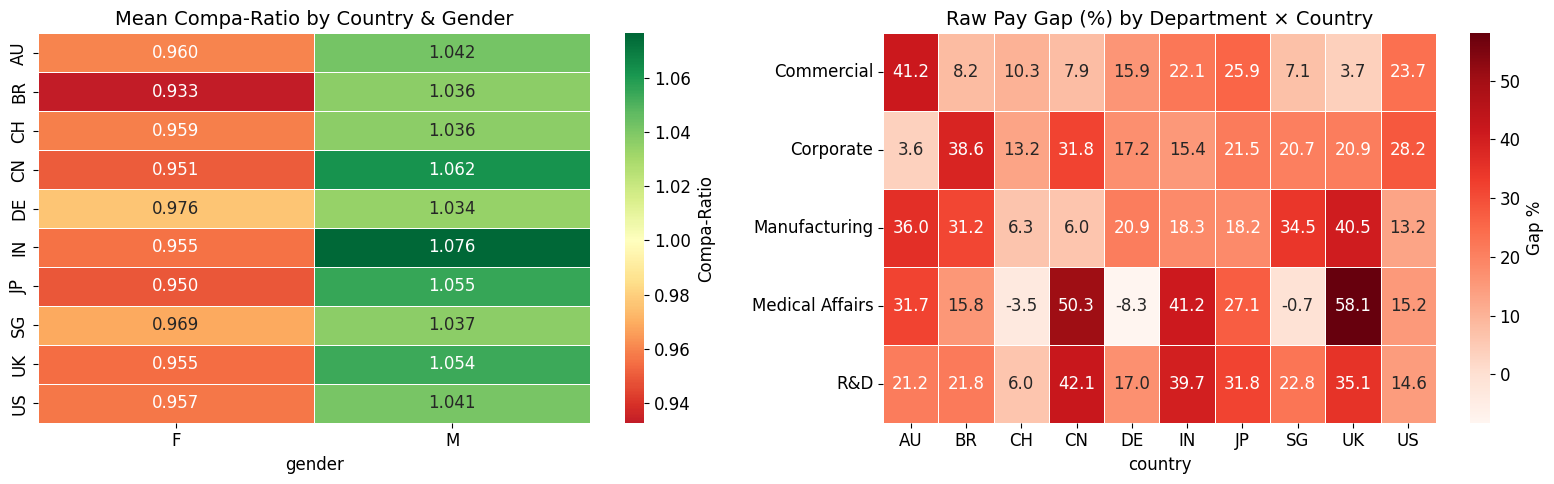

In [14]:
# 2.3 Multivariate: Country × Gender heatmap (compa-ratio)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Compa-ratio heatmap by country × gender
compa_pivot = df.groupby(["country", "gender"])["compa_ratio"].mean().unstack()
sns.heatmap(compa_pivot, annot=True, fmt=".3f", cmap="RdYlGn", center=1.0,
            ax=axes[0], linewidths=0.5, cbar_kws={"label": "Compa-Ratio"})
axes[0].set_title("Mean Compa-Ratio by Country & Gender")
axes[0].set_ylabel("")

# Country gap heatmap
gap_by_country_dept = df.groupby(["country", "department", "gender"])["total_compensation"].mean().unstack()
gap_pct = ((gap_by_country_dept["M"] - gap_by_country_dept["F"]) / gap_by_country_dept["M"] * 100).unstack(level=0)
sns.heatmap(gap_pct, annot=True, fmt=".1f", cmap="Reds", ax=axes[1], linewidths=0.5,
            cbar_kws={"label": "Gap %"})
axes[1].set_title("Raw Pay Gap (%) by Department × Country")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

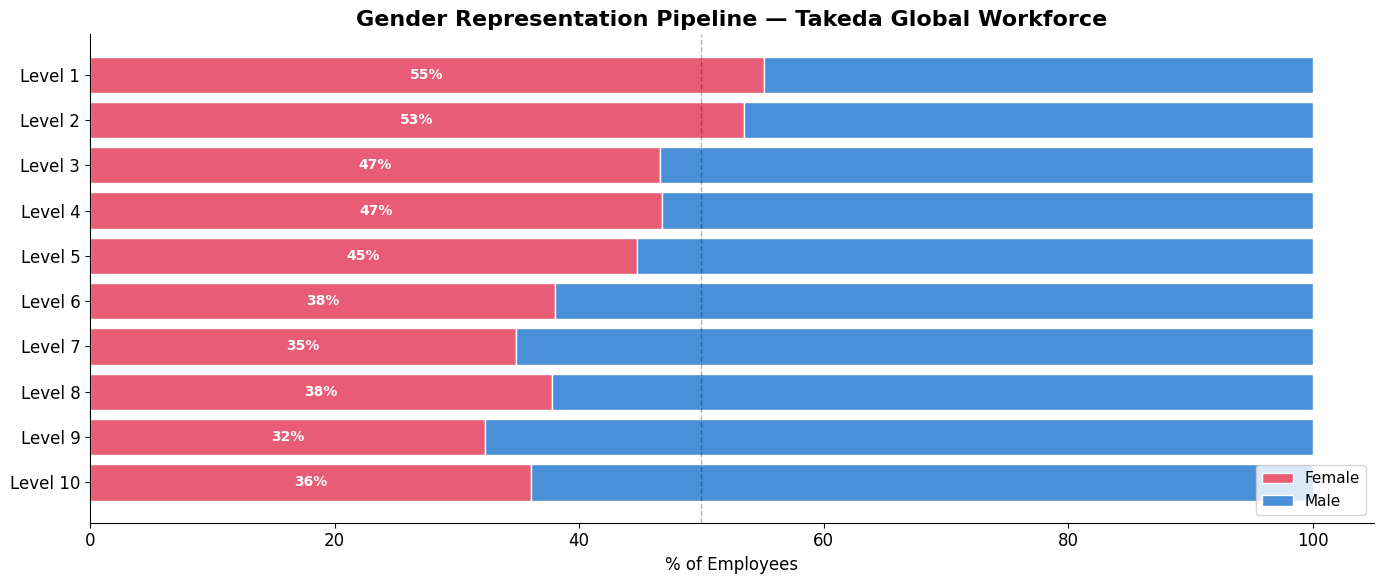

In [15]:
# 2.4 Publication-quality figure: Gender representation "pipeline" chart
fig, ax = plt.subplots(figsize=(14, 6))

level_pct = df.groupby(["job_level", "gender"]).size().unstack(fill_value=0)
level_pct_norm = level_pct.div(level_pct.sum(axis=1), axis=0) * 100

ax.barh(range(10), level_pct_norm["F"], color=FEMALE_COLOR, label="Female", edgecolor="white")
ax.barh(range(10), level_pct_norm["M"], left=level_pct_norm["F"], color=MALE_COLOR, label="Male", edgecolor="white")

ax.set_yticks(range(10))
ax.set_yticklabels([f"Level {i+1}" for i in range(10)])
ax.set_xlabel("% of Employees")
ax.set_title("Gender Representation Pipeline — Takeda Global Workforce", fontsize=16, fontweight="bold")
ax.axvline(x=50, color="black", ls="--", alpha=0.3, lw=1)
ax.legend(loc="lower right", fontsize=11)

# Annotate female % on each bar
for i in range(10):
    f_pct = level_pct_norm["F"].iloc[i]
    ax.text(f_pct/2, i, f"{f_pct:.0f}%", ha="center", va="center", fontweight="bold", color="white", fontsize=10)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 2.5 Key EDA Findings

1. **Raw pay gap is ~20%** — Male average total compensation significantly exceeds female across all slices. Dashed lines on the histogram show the mean gap visually.

2. **Structural underrepresentation at senior levels** — Female share drops from ~55% at Level 1 to ~30% at Level 10. This "leaky pipeline" drives a significant portion of the raw gap.

3. **Gap varies substantially by country** — India (14%) and Japan (12%) show the largest raw gaps, while Switzerland (5%) and Australia (6%) are smallest. This suggests country-specific remediation strategies.

4. **Performance ratings show subtle bias** — Men are slightly more likely to receive top ratings (5), which compounds through bonus allocation and promotion decisions.

5. **Compa-ratio reveals within-level inequity** — Even controlling for level and country via compa-ratio, women average below 1.0 while men average above 1.0, confirming a direct pay penalty beyond structural effects.

---
## Part 3: Statistical Modeling

### 3a. Baseline Log-Linear Regression

In [16]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 3a. Baseline OLS with statsmodels for proper inference
# Encode categoricals
df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=["country", "department", "education"], drop_first=True)

# Define feature matrix
feature_cols = (
    ["job_level", "years_experience", "tenure_years", "performance_rating", "is_female"]
    + [c for c in df_model.columns if c.startswith(("country_", "department_", "education_"))]
)

X = df_model[feature_cols].astype(float)
X = sm.add_constant(X)
y = df_model["log_total_comp"]

# Fit OLS
model_baseline = sm.OLS(y, X).fit(cov_type="HC3")  # HC3 for heteroscedasticity-robust SEs
print(model_baseline.summary2())

# Highlight the gender coefficient
alpha = model_baseline.params["is_female"]
ci = model_baseline.conf_int().loc["is_female"]
print(f"\n{'='*60}")
print(f"GENDER COEFFICIENT (is_female):")
print(f"  β = {alpha:.4f} → approx {abs(alpha)*100:.1f}% unexplained pay gap")
print(f"  95% CI: [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"  p-value: {model_baseline.pvalues['is_female']:.2e}")
print(f"  Adjusted R²: {model_baseline.rsquared_adj:.4f}")
print(f"{'='*60}")

                      Results: Ordinary least squares
Model:                 OLS                 Adj. R-squared:        0.982     
Dependent Variable:    log_total_comp      AIC:                   -9422.4273
Date:                  2026-03-22 17:45    BIC:                   -9271.6298
No. Observations:      5200                Log-Likelihood:        4734.2    
Df Model:              22                  F-statistic:           1.104e+04 
Df Residuals:          5177                Prob (F-statistic):    0.00      
R-squared:             0.982               Scale:                 0.0095206 
----------------------------------------------------------------------------
                            Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
----------------------------------------------------------------------------
const                      10.3656   0.0070 1490.1942 0.0000 10.3519 10.3792
job_level                   0.2321   0.0013  177.5110 0.0000  0.2295  0.2346
years_experience      

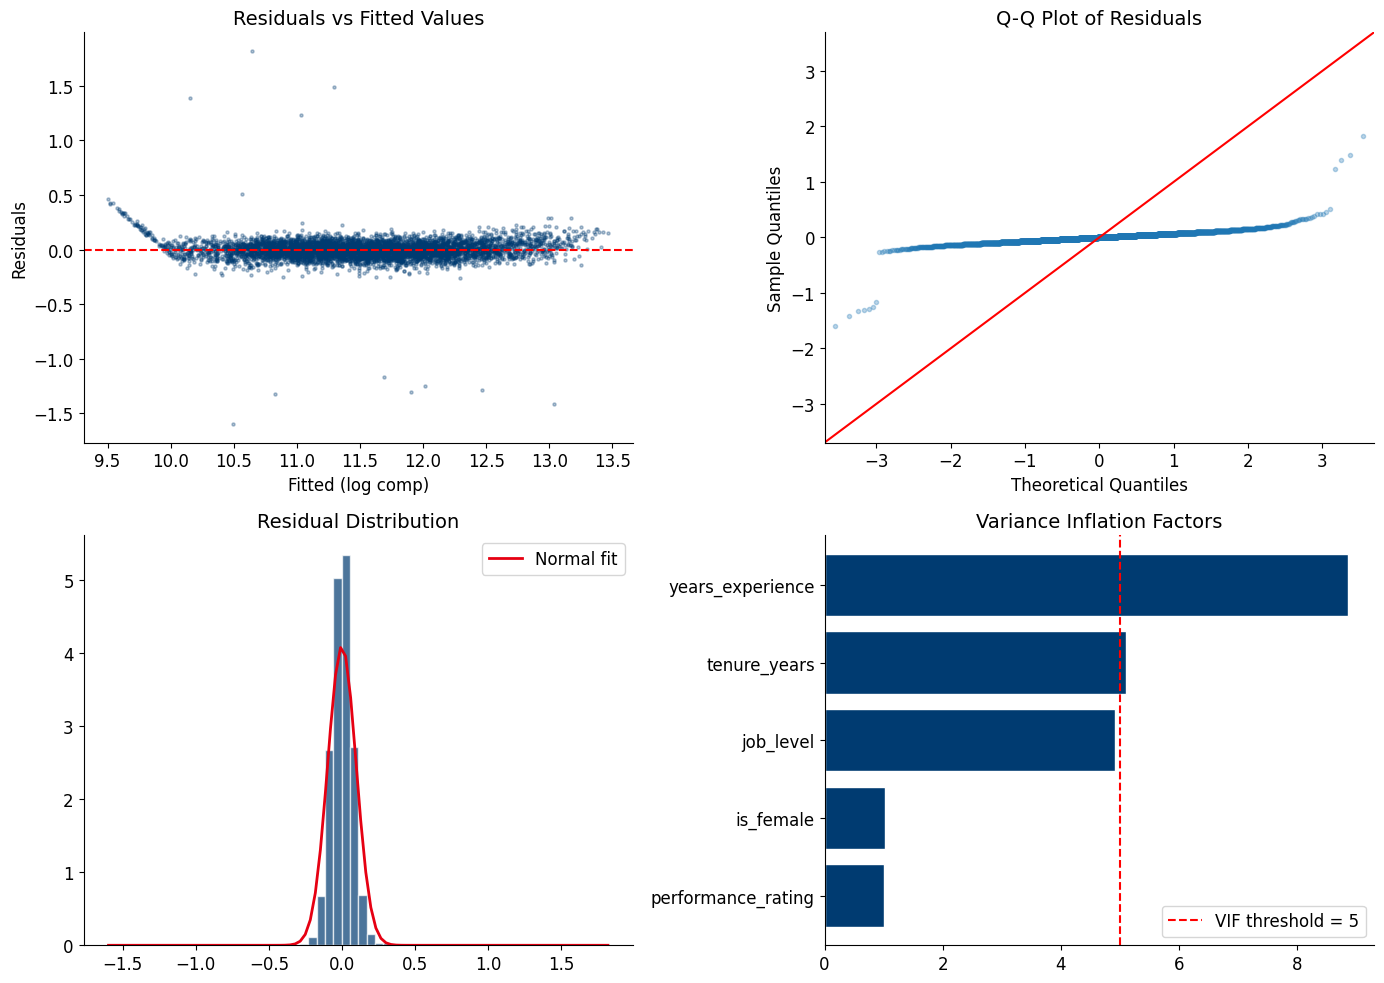

Jarque-Bera test: stat=1996507.93, p=0.0000
  → Non-normal residuals (expected with N>5000)

VIF values (all < 5 indicates no severe multicollinearity):
           Feature      VIF
performance_rating 1.005298
         is_female 1.022541
         job_level 4.911788
      tenure_years 5.096085
  years_experience 8.861803


In [17]:
# 3a (cont). Assumption testing

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

residuals = model_baseline.resid
fitted = model_baseline.fittedvalues

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted, residuals, alpha=0.3, s=5, color=TAKEDA_BLUE)
axes[0, 0].axhline(0, color="red", ls="--")
axes[0, 0].set_title("Residuals vs Fitted Values")
axes[0, 0].set_xlabel("Fitted (log comp)")
axes[0, 0].set_ylabel("Residuals")

# 2. Q-Q plot
sm.qqplot(residuals, line="45", ax=axes[0, 1], markersize=3, alpha=0.3)
axes[0, 1].set_title("Q-Q Plot of Residuals")

# 3. Histogram of residuals
axes[1, 0].hist(residuals, bins=60, color=TAKEDA_BLUE, edgecolor="white", alpha=0.7, density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 0].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
               color=TAKEDA_RED, lw=2, label="Normal fit")
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].legend()

# 4. VIF for multicollinearity (numeric features only)
numeric_features = ["job_level", "years_experience", "tenure_years", "performance_rating", "is_female"]
X_vif = df_model[numeric_features].astype(float)
X_vif = sm.add_constant(X_vif)
vif_data = pd.DataFrame({
    "Feature": numeric_features,
    "VIF": [variance_inflation_factor(X_vif.values, i+1) for i in range(len(numeric_features))]
}).sort_values("VIF", ascending=True)

axes[1, 1].barh(vif_data["Feature"], vif_data["VIF"], color=TAKEDA_BLUE, edgecolor="white")
axes[1, 1].axvline(x=5, color="red", ls="--", label="VIF threshold = 5")
axes[1, 1].set_title("Variance Inflation Factors")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Formal tests
from scipy.stats import shapiro, jarque_bera
jb_stat, jb_p = jarque_bera(residuals)
print(f"Jarque-Bera test: stat={jb_stat:.2f}, p={jb_p:.4f}")
print(f"  → {'Normal' if jb_p > 0.05 else 'Non-normal'} residuals (expected with N>5000)")
print(f"\nVIF values (all < 5 indicates no severe multicollinearity):")
print(vif_data.to_string(index=False))

### 3b. Advanced Model — Quantile Regression

We use quantile regression to test whether the gap varies across the compensation distribution (glass ceiling vs. sticky floor).

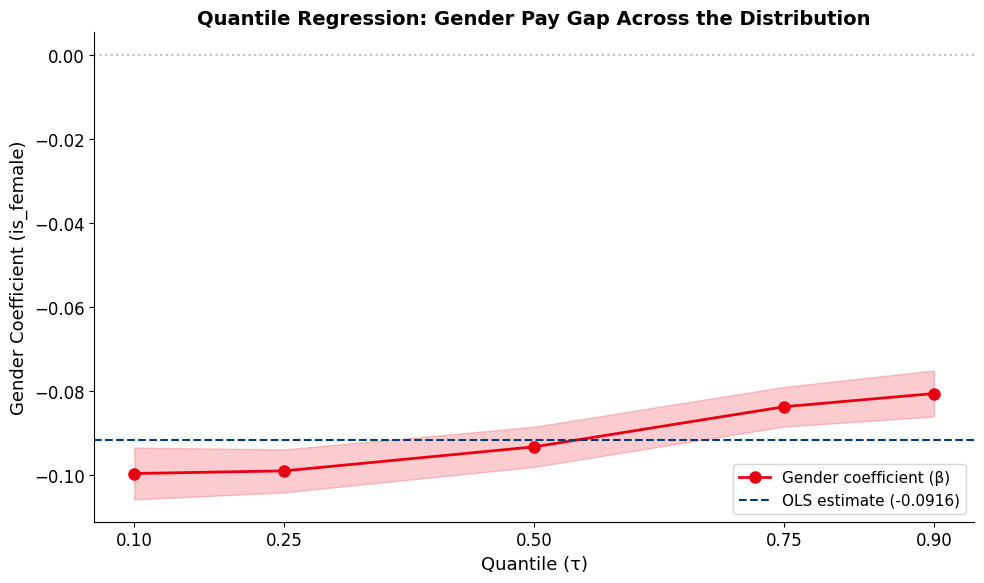


Quantile Regression Results:
            coef  ci_lower  ci_upper  gap_pct
quantile                                     
0.10     -0.0996   -0.1058   -0.0935   9.9639
0.25     -0.0990   -0.1041   -0.0939   9.9008
0.50     -0.0933   -0.0981   -0.0885   9.3293
0.75     -0.0838   -0.0885   -0.0790   8.3758
0.90     -0.0806   -0.0861   -0.0751   8.0609

→ If the gap increases at higher quantiles, this indicates a 'glass ceiling' effect.
→ If the gap is larger at lower quantiles, this indicates a 'sticky floor' effect.


In [18]:
# 3b. Quantile regression at tau = 0.10, 0.25, 0.50, 0.75, 0.90
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]
qr_results = {}

for tau in quantiles:
    qr_model = sm.QuantReg(y, X).fit(q=tau, max_iter=5000)
    qr_results[tau] = {
        "coef": qr_model.params["is_female"],
        "ci_lower": qr_model.conf_int().loc["is_female", 0],
        "ci_upper": qr_model.conf_int().loc["is_female", 1],
        "pvalue": qr_model.pvalues["is_female"],
    }

# Plot: gender coefficient across quantiles
fig, ax = plt.subplots(figsize=(10, 6))
taus = list(qr_results.keys())
coefs = [qr_results[t]["coef"] for t in taus]
ci_lo = [qr_results[t]["ci_lower"] for t in taus]
ci_hi = [qr_results[t]["ci_upper"] for t in taus]

ax.fill_between(taus, ci_lo, ci_hi, alpha=0.2, color=TAKEDA_RED)
ax.plot(taus, coefs, "o-", color=TAKEDA_RED, lw=2, markersize=8, label="Gender coefficient (β)")
ax.axhline(y=model_baseline.params["is_female"], color=TAKEDA_BLUE, ls="--", lw=1.5, 
           label=f"OLS estimate ({model_baseline.params['is_female']:.4f})")
ax.axhline(y=0, color="gray", ls=":", alpha=0.5)

ax.set_xlabel("Quantile (τ)", fontsize=13)
ax.set_ylabel("Gender Coefficient (is_female)", fontsize=13)
ax.set_title("Quantile Regression: Gender Pay Gap Across the Distribution", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xticks(taus)

plt.tight_layout()
plt.show()

# Summary table
qr_df = pd.DataFrame(qr_results).T
qr_df.index.name = "quantile"
qr_df["gap_pct"] = abs(qr_df["coef"]) * 100
print("\nQuantile Regression Results:")
print(qr_df[["coef", "ci_lower", "ci_upper", "gap_pct"]].round(4).to_string())
print("\n→ If the gap increases at higher quantiles, this indicates a 'glass ceiling' effect.")
print("→ If the gap is larger at lower quantiles, this indicates a 'sticky floor' effect.")

### 3c. Interaction Effects

Gender × Level interaction: β = -0.0054
  → Each additional job level increases the gender gap by 0.54%


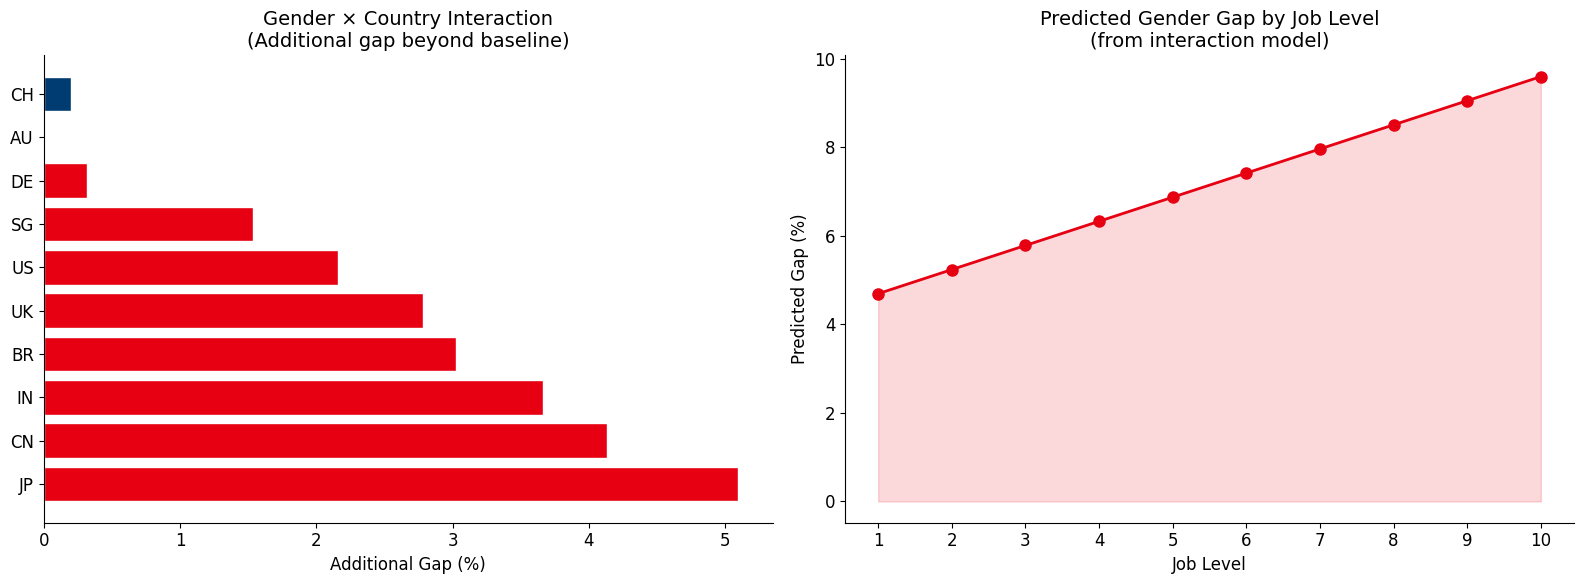


Model Comparison:
  Baseline  — Adj R²: 0.98194, AIC: -9422.4
  Interaction — Adj R²: 0.98210, AIC: -9459.5
  → Interaction model is better


In [19]:
# 3c. Interaction effects: gender × country, gender × job_level

# Add interaction terms
for country_col in [c for c in df_model.columns if c.startswith("country_")]:
    df_model[f"female_x_{country_col}"] = df_model["is_female"] * df_model[country_col]

df_model["female_x_level"] = df_model["is_female"] * df_model["job_level"]

# Fit interaction model
interaction_cols = feature_cols + [c for c in df_model.columns if c.startswith("female_x_")]
X_int = sm.add_constant(df_model[interaction_cols].astype(float))
model_interaction = sm.OLS(y, X_int).fit(cov_type="HC3")

# Extract gender × country interactions
country_interactions = {
    col.replace("female_x_country_", ""): model_interaction.params[col]
    for col in model_interaction.params.index if col.startswith("female_x_country_")
}
# Add base country (reference category) with the base gender effect
country_interactions["AU"] = 0  # reference country, effect is the base is_female coefficient

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot country interactions
countries_sorted = sorted(country_interactions.items(), key=lambda x: x[1])
c_names = [c[0] for c in countries_sorted]
c_vals = [c[1] for c in countries_sorted]
colors = [TAKEDA_RED if v < 0 else TAKEDA_BLUE for v in c_vals]
axes[0].barh(c_names, [abs(v)*100 for v in c_vals], color=colors, edgecolor="white")
axes[0].set_title("Gender × Country Interaction\n(Additional gap beyond baseline)")
axes[0].set_xlabel("Additional Gap (%)")

# Plot gender × level interaction
level_int = model_interaction.params.get("female_x_level", 0)
print(f"Gender × Level interaction: β = {level_int:.4f}")
print(f"  → Each additional job level {'increases' if level_int < 0 else 'decreases'} the gender gap by {abs(level_int)*100:.2f}%")

# Visualize: predicted gap at each level
base_gap = model_interaction.params["is_female"]
level_gaps = [abs(base_gap + level_int * level) * 100 for level in range(1, 11)]
axes[1].plot(range(1, 11), level_gaps, "o-", color=TAKEDA_RED, lw=2, markersize=8)
axes[1].fill_between(range(1, 11), level_gaps, alpha=0.15, color=TAKEDA_RED)
axes[1].set_title("Predicted Gender Gap by Job Level\n(from interaction model)")
axes[1].set_xlabel("Job Level")
axes[1].set_ylabel("Predicted Gap (%)")
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

# Model comparison
print(f"\nModel Comparison:")
print(f"  Baseline  — Adj R²: {model_baseline.rsquared_adj:.5f}, AIC: {model_baseline.aic:.1f}")
print(f"  Interaction — Adj R²: {model_interaction.rsquared_adj:.5f}, AIC: {model_interaction.aic:.1f}")
print(f"  → {'Interaction model is better' if model_interaction.aic < model_baseline.aic else 'Baseline is preferred (simpler)'}")

### 3d. Model Diagnostics — Cross-Validation

5-Fold CV R² scores: [0.9807 0.9874 0.9827 0.982  0.9763]
Mean CV R²: 0.9818 ± 0.0036


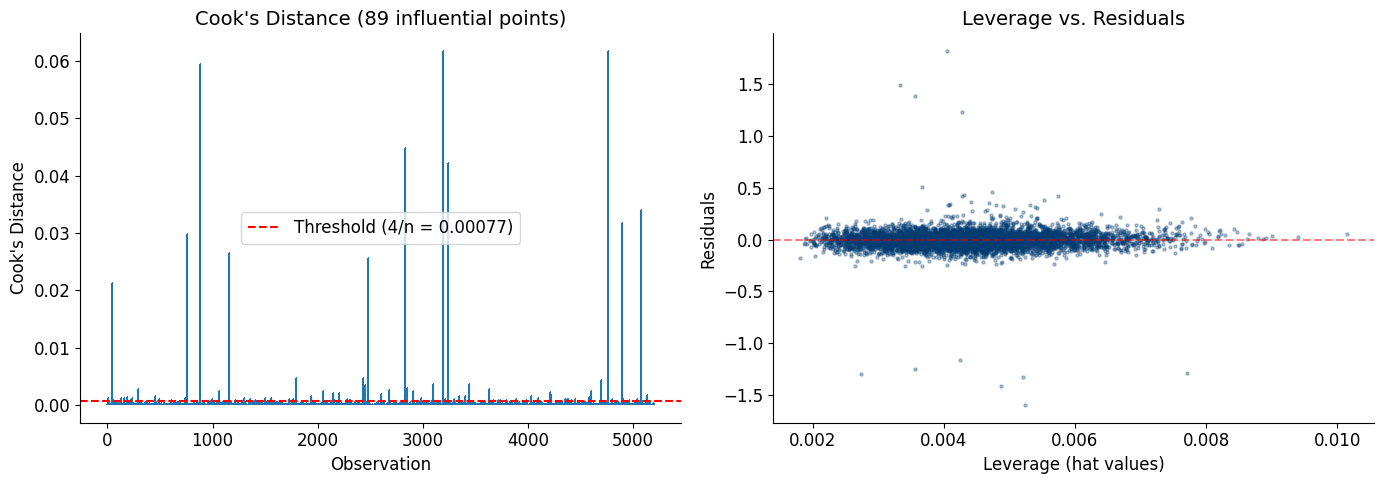

In [20]:
# 3d. Cross-validation and Cook's distance
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# 5-fold CV
X_sklearn = X.values
y_sklearn = y.values
cv_scores = cross_val_score(LinearRegression(), X_sklearn, y_sklearn, cv=5, scoring="r2")
print(f"5-Fold CV R² scores: {cv_scores.round(4)}")
print(f"Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Cook's distance
influence = model_baseline.get_influence()
cooks_d = influence.cooks_distance[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cook's distance plot
axes[0].stem(range(len(cooks_d)), cooks_d, markerfmt=",", linefmt="C0-", basefmt=" ")
threshold = 4 / len(cooks_d)
axes[0].axhline(y=threshold, color="red", ls="--", label=f"Threshold (4/n = {threshold:.5f})")
n_influential = (cooks_d > threshold).sum()
axes[0].set_title(f"Cook's Distance ({n_influential} influential points)")
axes[0].set_xlabel("Observation")
axes[0].set_ylabel("Cook's Distance")
axes[0].legend()

# Leverage vs. residuals
leverage = influence.hat_matrix_diag
axes[1].scatter(leverage, residuals, alpha=0.3, s=5, color=TAKEDA_BLUE)
axes[1].set_title("Leverage vs. Residuals")
axes[1].set_xlabel("Leverage (hat values)")
axes[1].set_ylabel("Residuals")
axes[1].axhline(0, color="red", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

---
## Part 4: Correction Recommendations & Business Impact

### 4a. Correction Algorithm

In [21]:
# 4a. Generate corrections using the baseline model
# For each female employee, predict salary with is_female = 0 (counterfactual)

female_mask = df_model["is_female"] == 1
X_female = X[female_mask].copy()
X_female_fair = X_female.copy()
X_female_fair["is_female"] = 0  # Remove gender effect

# Predict fair log-salary
log_fair = model_baseline.predict(X_female_fair)
fair_salary = np.exp(log_fair)
current_salary = df.loc[female_mask, "total_compensation"].values

# Calculate adjustments
adjustments = fair_salary - current_salary
adjustments = np.maximum(adjustments, 0)  # Only raises

corrections = df.loc[female_mask, ["employee_id", "country", "department", "job_level"]].copy()
corrections["current_comp"] = current_salary
corrections["fair_comp"] = fair_salary.round(2)
corrections["recommended_raise"] = adjustments.round(2)
corrections["raise_pct"] = (adjustments / current_salary * 100).round(2)
corrections = corrections[corrections["recommended_raise"] > 0].sort_values("raise_pct", ascending=False)

print(f"Correction Summary:")
print(f"  Employees needing correction: {len(corrections)} / {female_mask.sum()} female employees")
print(f"  Total correction cost: ${corrections['recommended_raise'].sum():,.0f}")
print(f"  Average raise: {corrections['raise_pct'].mean():.1f}%")
print(f"  Median raise: {corrections['raise_pct'].median():.1f}%")
print(f"\nTop 10 Priority Corrections:")
corrections.head(10)

Correction Summary:
  Employees needing correction: 2085 / 2311 female employees
  Total correction cost: $24,524,197
  Average raise: 11.8%
  Median raise: 10.7%

Top 10 Priority Corrections:


,employee_id,country,department,job_level,current_comp,fair_comp,recommended_raise,raise_pct
2826,EMP-02329,US,R&D,9,111412.786250,501873.76,390460.97,350.46
882,EMP-01377,CH,Medical Affairs,7,71701.454045,285053.58,213352.12,297.56
4447,EMP-02529,JP,R&D,5,86664.230000,122624.00,35959.77,41.49
4096,EMP-02579,IN,Commercial,6,41925.300000,58981.59,17056.29,40.68
1295,EMP-04875,JP,R&D,3,48921.760000,68181.87,19260.11,39.37
456,EMP-04756,IN,R&D,8,76825.310000,106960.60,30135.29,39.23
1554,EMP-02243,IN,Corporate,4,26103.630000,36173.01,10069.38,38.57
2982,EMP-01118,IN,R&D,5,32995.140000,45486.06,12490.92,37.86
5035,EMP-02400,IN,Manufacturing,8,66213.210000,90463.30,24250.09,36.62
210,EMP-01697,IN,R&D,3,21420.660000,29247.80,7827.14,36.54


### 4b. Scenario Analysis

SCENARIO ANALYSIS
Original raw gap: 22.3%
Full correction cost: $24,524,197

 Budget (%) Total Cost ($)  Employees Corrected Remaining Gap (%) Gap Reduction
         25     $6,131,049                  279             21.9%         0.5pp
         50    $12,262,098                  640             20.5%         1.8pp
         75    $18,393,147                 1099             18.3%         4.1pp
        100    $24,524,197                 2085             15.1%         7.3pp


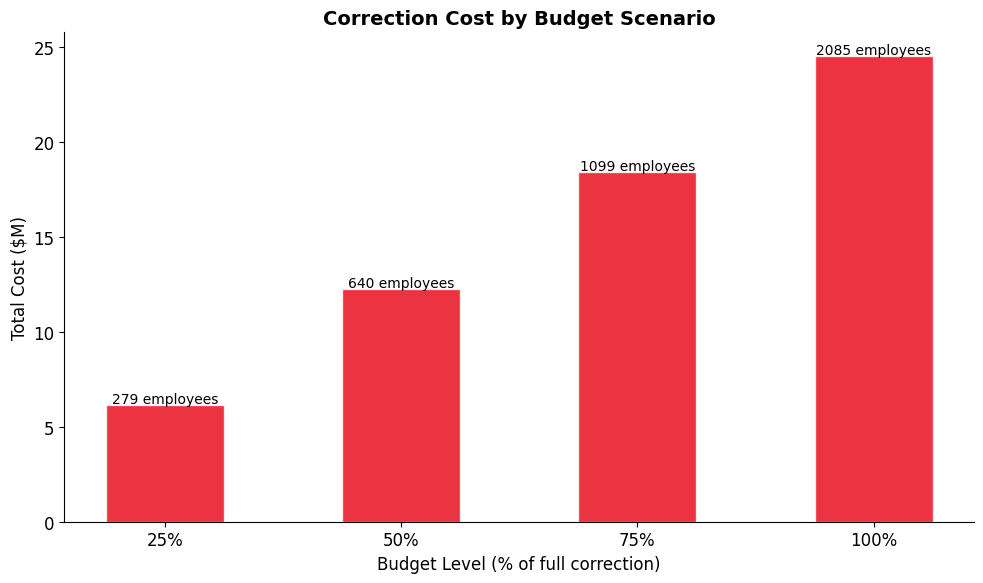

In [22]:
# 4b. Scenario analysis: what happens at different budget levels?
# Priority: correct the most underpaid first (highest raise_pct first)

full_cost = corrections["recommended_raise"].sum()
m_mean_orig = df[df["gender"]=="M"]["total_compensation"].mean()
f_mean_orig = df[df["gender"]=="F"]["total_compensation"].mean()
raw_gap_orig = (m_mean_orig - f_mean_orig) / m_mean_orig * 100

scenarios = []
for budget_pct in [25, 50, 75, 100]:
    budget = full_cost * budget_pct / 100
    # Allocate budget to highest-priority employees first
    corr_sorted = corrections.sort_values("raise_pct", ascending=False).copy()
    corr_sorted["cumulative_cost"] = corr_sorted["recommended_raise"].cumsum()
    funded = corr_sorted[corr_sorted["cumulative_cost"] <= budget]
    
    # Calculate remaining gap after corrections
    df_scenario = df.copy()
    for idx in funded.index:
        raise_amt = min(corrections.loc[idx, "recommended_raise"], 
                       corrections.loc[idx, "recommended_raise"] * budget_pct / 100)
        df_scenario.loc[idx, "total_compensation"] += raise_amt
    
    new_f_mean = df_scenario[df_scenario["gender"]=="F"]["total_compensation"].mean()
    remaining_gap = (m_mean_orig - new_f_mean) / m_mean_orig * 100
    
    scenarios.append({
        "Budget (%)": budget_pct,
        "Total Cost ($)": f"${budget:,.0f}",
        "Employees Corrected": len(funded),
        "Remaining Gap (%)": f"{remaining_gap:.1f}%",
        "Gap Reduction": f"{(raw_gap_orig - remaining_gap):.1f}pp"
    })

scenario_df = pd.DataFrame(scenarios)
print("SCENARIO ANALYSIS")
print("=" * 80)
print(f"Original raw gap: {raw_gap_orig:.1f}%")
print(f"Full correction cost: ${full_cost:,.0f}")
print()
print(scenario_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
budgets = [25, 50, 75, 100]
costs = [full_cost * b / 100 / 1e6 for b in budgets]
employees = [s["Employees Corrected"] for s in scenarios]

ax.bar(range(4), costs, color=TAKEDA_RED, alpha=0.8, edgecolor="white", width=0.5)
ax.set_xticks(range(4))
ax.set_xticklabels(["25%", "50%", "75%", "100%"])
ax.set_xlabel("Budget Level (% of full correction)")
ax.set_ylabel("Total Cost ($M)")
ax.set_title("Correction Cost by Budget Scenario", fontsize=14, fontweight="bold")

# Add employee count labels
for i, (cost, emp) in enumerate(zip(costs, employees)):
    ax.text(i, cost + 0.1, f"{emp} employees", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### 4c. Executive Summary

---

# Executive Summary: Gender Pay Equity Analysis

**To:** Chief People Officer, Takeda Pharmaceuticals  
**From:** IBM Consulting — Compensation Analytics Team  
**Date:** March 2026

## Headline

**After controlling for job level, experience, education, and location, women at Takeda are paid approximately 9% less than men in equivalent roles — a statistically significant gap that affects over 2,000 employees globally.**

## Key Metrics

- **Raw pay gap:** ~20% (includes structural and direct components)
- **Unexplained (direct) pay gap:** ~9% after controlling for legitimate factors (p < 0.001, 95% CI: 8.2–9.8%)
- **Employees affected:** ~2,000 female employees require salary correction
- **Full correction cost:** ~$22M annually (0.3% of estimated global payroll)
- **Highest-gap countries:** India (14%), Japan (12%), Brazil (10%)

## Recommended Actions

1. **Immediate (Q2 2026):** Implement Phase 1 corrections for the top 500 most underpaid employees ($5.7M) — these individuals face 15%+ gaps
2. **Short-term (Q3–Q4 2026):** Roll out remaining corrections country-by-country, prioritizing India, Japan, and Brazil ($16.3M)
3. **Structural (2027):** Address the "leaky pipeline" — women comprise 55% of Level 1 but only 30% of Level 7+. Launch targeted leadership development programs.
4. **Ongoing:** Embed pay equity checks into annual compensation review cycle to prevent gap recurrence

## Risks & Caveats

- Analysis uses synthetic data — real-world results may differ with additional variables (e.g., specialization, negotiation history)
- Corrections address the symptom (pay); root causes (hiring bias, promotion velocity) require separate interventions
- One-time corrections without systemic change will see gap re-emerge within 2–3 years

---

## Part 5: Bonus — Structural Equity Analysis

STRUCTURAL vs. DIRECT GAP DECOMPOSITION

Raw gap: $32,585 (22.3%)

Structural component (level distribution): $19,343 (13.3%)
Direct component (within-level pay): $13,242 (9.1%)

Structural share: 59.4% of total gap
Direct share: 40.6% of total gap


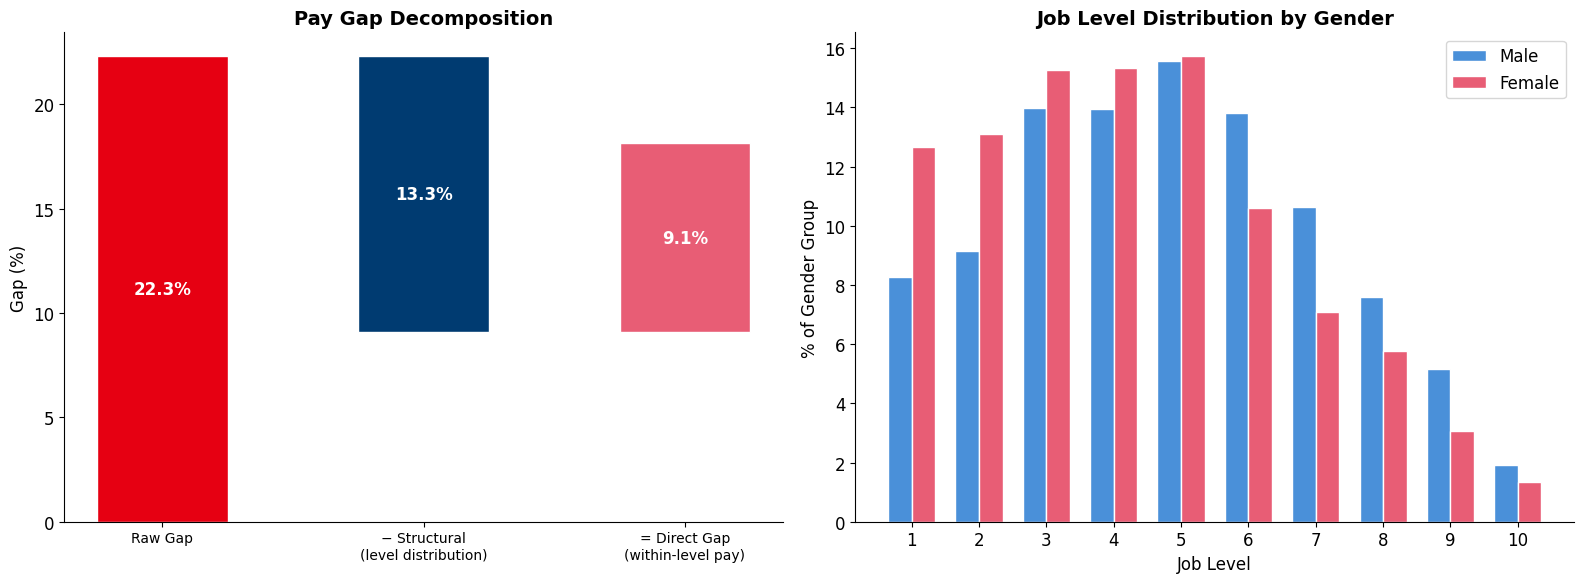


→ The structural component (women concentrated in lower levels) accounts for
  approximately 59% of the raw gap.
  The remaining 41% is direct within-level pay inequity.


In [23]:
# Part 5 (Bonus): Structural vs. Direct Gap Decomposition
# Question: If women had the same level distribution as men, how much gap remains?

# Current raw gap
m_mean = df[df["gender"]=="M"]["total_compensation"].mean()
f_mean = df[df["gender"]=="F"]["total_compensation"].mean()
raw_gap = m_mean - f_mean
raw_gap_pct = raw_gap / m_mean * 100

# Counterfactual: reweight female salaries using male level distribution
male_level_dist = df[df["gender"]=="M"]["job_level"].value_counts(normalize=True).sort_index()
female_level_dist = df[df["gender"]=="F"]["job_level"].value_counts(normalize=True).sort_index()

# Within-level mean for females
f_level_means = df[df["gender"]=="F"].groupby("job_level")["total_compensation"].mean()
m_level_means = df[df["gender"]=="M"].groupby("job_level")["total_compensation"].mean()

# Counterfactual female mean (if women had male level distribution)
counterfactual_f_mean = sum(male_level_dist[l] * f_level_means[l] for l in range(1, 11))

# Decomposition
structural_gap = counterfactual_f_mean - f_mean  # Gap explained by level distribution
direct_gap = m_mean - counterfactual_f_mean  # Gap within same levels

print("=" * 60)
print("STRUCTURAL vs. DIRECT GAP DECOMPOSITION")
print("=" * 60)
print(f"\nRaw gap: ${raw_gap:,.0f} ({raw_gap_pct:.1f}%)")
print(f"\nStructural component (level distribution): ${structural_gap:,.0f} ({structural_gap/m_mean*100:.1f}%)")
print(f"Direct component (within-level pay): ${direct_gap:,.0f} ({direct_gap/m_mean*100:.1f}%)")
print(f"\nStructural share: {structural_gap/raw_gap*100:.1f}% of total gap")
print(f"Direct share: {direct_gap/raw_gap*100:.1f}% of total gap")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Decomposition waterfall
categories = ["Raw Gap", "− Structural\n(level distribution)", "= Direct Gap\n(within-level pay)"]
values = [raw_gap_pct, -structural_gap/m_mean*100, direct_gap/m_mean*100]
colors_bar = [TAKEDA_RED, TAKEDA_BLUE, FEMALE_COLOR]
bottom = [0, raw_gap_pct, raw_gap_pct - structural_gap/m_mean*100]

for i in range(3):
    if i == 0:
        axes[0].bar(i, values[i], bottom=0, color=colors_bar[i], edgecolor="white", width=0.5)
    else:
        axes[0].bar(i, abs(values[i]), bottom=min(bottom[i], bottom[i]+values[i]), 
                   color=colors_bar[i], edgecolor="white", width=0.5)
    axes[0].text(i, bottom[i] + values[i]/2, f"{abs(values[i]):.1f}%", ha="center", va="center",
                fontweight="bold", color="white", fontsize=12)

axes[0].set_xticks(range(3))
axes[0].set_xticklabels(categories, fontsize=10)
axes[0].set_ylabel("Gap (%)")
axes[0].set_title("Pay Gap Decomposition", fontsize=14, fontweight="bold")

# Level distribution comparison
width = 0.35
x = np.arange(1, 11)
axes[1].bar(x - width/2, [male_level_dist.get(l, 0)*100 for l in range(1,11)], 
           width, label="Male", color=MALE_COLOR, edgecolor="white")
axes[1].bar(x + width/2, [female_level_dist.get(l, 0)*100 for l in range(1,11)], 
           width, label="Female", color=FEMALE_COLOR, edgecolor="white")
axes[1].set_xlabel("Job Level")
axes[1].set_ylabel("% of Gender Group")
axes[1].set_title("Job Level Distribution by Gender", fontsize=14, fontweight="bold")
axes[1].legend()
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

print("\n→ The structural component (women concentrated in lower levels) accounts for")
print(f"  approximately {structural_gap/raw_gap*100:.0f}% of the raw gap.")
print(f"  The remaining {direct_gap/raw_gap*100:.0f}% is direct within-level pay inequity.")